In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.svm import SVR
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import ttest_rel
from sklearn.compose import TransformedTargetRegressor

In [3]:
df = pd.read_csv('Time Data - Sheet3.csv')

In [5]:
target = 'Dev Time (Days)'
predictor = 'total_swag'

df_pr = df[[predictor, target]].dropna()
df_pr['total_swag'] = (pd.to_numeric(df_pr['total_swag'].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float64'))

r2_rom = r2_score(df_pr[target],(df_pr[predictor])*30)
mae_rom = mean_absolute_error(df_pr[target],df_pr[predictor])

print("R2 Score:", r2_rom)
print("MAE:", mae_rom)

R2 Score: -22057125.824638877
MAE: 31269.089140292643


<Axes: >

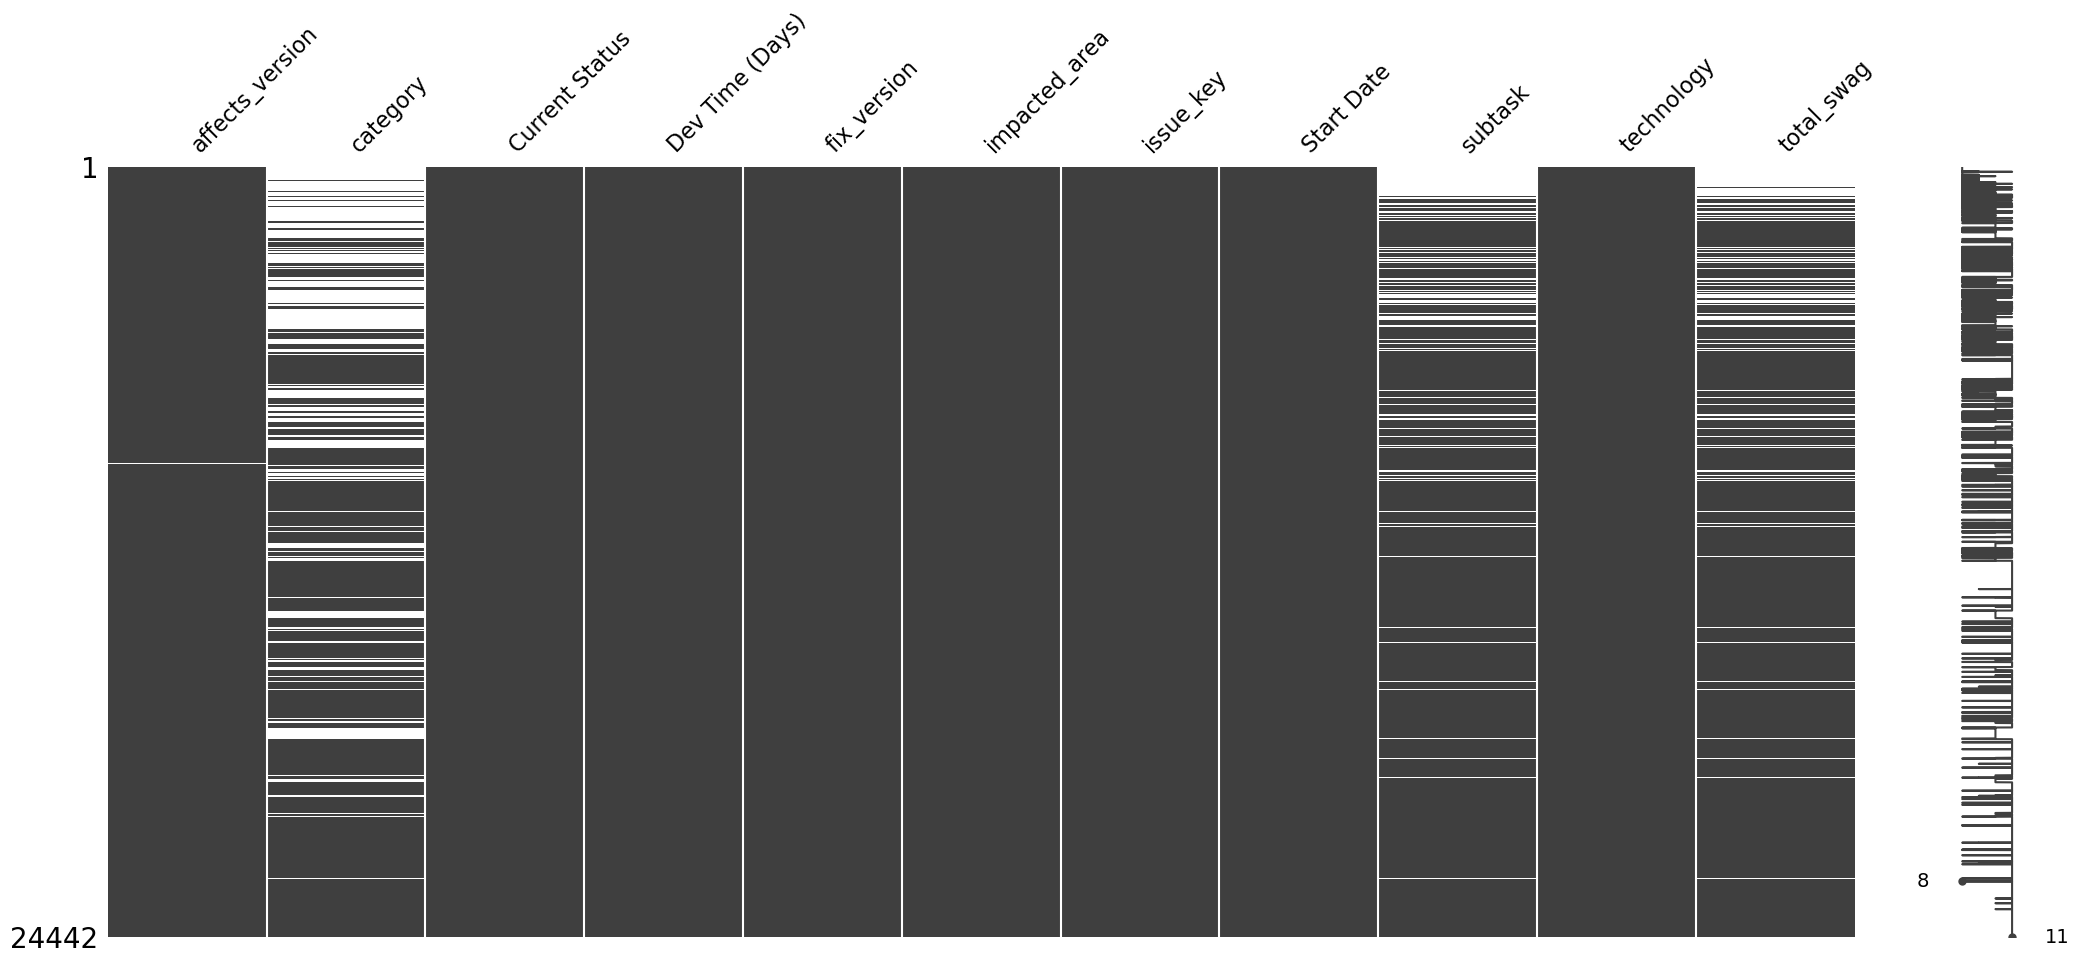

In [4]:
msno.matrix(df)

In [5]:
# Remove rows where the 'Dev Time (Days)' column is 0
df_filtered = df[df['Dev Time (Days)'] > 30]

print("Rows with 'Dev Time (Days)' equal to 0 or 1 have been removed.")

Rows with 'Dev Time (Days)' equal to 0 or 1 have been removed.


In [6]:
len(df), len(df_filtered)

(24442, 23775)

In [7]:
df_final = df_filtered.drop('subtask', axis=1)
df_final.drop_duplicates(inplace=True)

In [8]:
category_encoded = df_filtered['category'].str.strip().str.get_dummies(sep=',').astype(int)

df_encoded = pd.get_dummies(df_filtered, columns=['impacted_area', 'technology','affects_version','fix_version'], dtype=int)

df_final = pd.concat([df_encoded, category_encoded], axis=1)
df_final = df_final.drop('category', axis =1)
df_final.head(50)

,Current Status,Dev Time (Days),issue_key,Start Date,subtask,total_swag,impacted_area_(none),impacted_area_3rd Party,impacted_area_AMS,impacted_area_ASTRO Infrastructure,...,Cyber RR,Engineering,One list,PDM,Parity/Evolution,Quality,Quality-ENG,Roadmap/PCN,SLT,Security
667,Closed,31,DEVASTRO-1317,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
668,Closed,31,DEVASTRO-1321,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
669,Closed,31,DEVASTRO-1318,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
670,Closed,31,DEVASTRO-1316,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
671,Closed,31,DEVASTRO-1320,09/06/2020 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
672,Closed,31,DEVASTRO-1713,14/09/2020 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
673,Closed,31,DEVASTRO-2840,19/07/2021 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
674,Closed,31,DEVASTRO-2842,19/07/2021 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
675,Closed,31,DEVASTRO-2841,19/07/2021 00:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
676,Closed,31,DEVASTRO-4950,02/05/2023 0:00:00,NaN,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df_final['total_swag']

667             NaN
668             NaN
669             NaN
670             NaN
671             NaN
            ...    
24437    386,620.80
24438    386,620.80
24439    386,620.80
24440    386,620.80
24441    386,620.80
Name: total_swag, Length: 23775, dtype: object

In [10]:
df_final['Start Date'].dtype

dtype('O')

In [11]:
df_final['Start Date'] = pd.to_datetime(df_final['Start Date'], dayfirst=True)

In [12]:
df_final['Start Date'] = df_final['Start Date'].dt.strftime('%Y%m%d').astype(int)

In [13]:
df_final['Start Date']

667      20200609
668      20200609
669      20200609
670      20200609
671      20200609
           ...   
24437    20180518
24438    20180518
24439    20180518
24440    20180518
24441    20180518
Name: Start Date, Length: 23775, dtype: int64

In [14]:
df_final.head(10)
print(df_final.select_dtypes(include='object').columns.tolist())

['Current Status', 'issue_key', 'subtask', 'total_swag']


In [15]:
df_final['total_swag'] = (pd.to_numeric(df_final['total_swag'].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float64'))

In [16]:
subtask_counts = df_final.groupby('issue_key')['subtask'].transform('nunique')

df_final['subtask_count'] = subtask_counts

df_final = df_final.drop(columns=['subtask'])

df_final = df_final.drop_duplicates(subset=['issue_key']).reset_index(drop=True)

df_final.head(10)

,Current Status,Dev Time (Days),issue_key,Start Date,total_swag,impacted_area_(none),impacted_area_3rd Party,impacted_area_AMS,impacted_area_ASTRO Infrastructure,impacted_area_Accessories,...,Engineering,One list,PDM,Parity/Evolution,Quality,Quality-ENG,Roadmap/PCN,SLT,Security,subtask_count
0,Closed,31,DEVASTRO-1317,20200609,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Closed,31,DEVASTRO-1321,20200609,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Closed,31,DEVASTRO-1318,20200609,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Closed,31,DEVASTRO-1316,20200609,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Closed,31,DEVASTRO-1320,20200609,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,Closed,31,DEVASTRO-1713,20200914,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Closed,31,DEVASTRO-2840,20210719,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,Closed,31,DEVASTRO-2842,20210719,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,Closed,31,DEVASTRO-2841,20210719,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,Closed,31,DEVASTRO-4950,20230502,NaN,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
df_final.to_csv('Data.csv')

Isolation Forest

In [18]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt


features_to_check = df_final.drop(['issue_key', 'Current Status'], axis=1)

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

preds = iso_forest.fit_predict(features_to_check)

df_final['anomaly_score'] = preds

In [19]:
df_iso = df_final[df_final['anomaly_score'] == 1].copy()

df_iso = df_iso.drop(columns=['anomaly_score'])

df_final = df_final.drop(columns=['anomaly_score'])

print(f"Original size: {len(df_final)}")
print(f"New size: {len(df_iso)}")
print(f"Removed {len(df_final) - len(df_iso)} outliers.")

Original size: 2766
New size: 2627
Removed 139 outliers.


IQR (Baseline)

In [20]:
Q1 = df_final[target].quantile(0.25)
Q3 = df_final[target].quantile(0.75)

df_iqr = df_final[(df_final[target] >= Q1) & (df_final[target] <= Q3)]

print(f"Original size: {len(df_final)}")
print(f"New size: {len(df_iqr)}")
print(f"Removed {len(df_final) - len(df_iqr)} outliers.")

Original size: 2766
New size: 1384
Removed 1382 outliers.


Local Outlier Factor (Density-Based Method)

In [28]:
# 1. We use the same 'df_clean_rows' you created to run the LOF
# (This is the subset with no NaNs used for the calculation)
df_clean_rows = df_final[columns_to_eval].dropna()
X_scaled = scaler.fit_transform(df_clean_rows)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_labels = lof.fit_predict(X_scaled)

# 2. Identify the specific indices of the -1 (outliers)
# df_clean_rows.index preserves the original row numbers from df_final
outlier_indices = df_clean_rows.index[outlier_labels == -1]

# 3. Drop ONLY those indices from the original df_final
df_final_clean = df_final.drop(outlier_indices).reset_index(drop=True)

print(f"Original df_final size: {len(df_final)}")
print(f"Specifically removed {len(outlier_indices)} multivariate outliers.")
print(f"Final dataset size: {len(df_final_clean)}")

Original df_final size: 2766
Specifically removed 31 multivariate outliers.
Final dataset size: 2735


In [29]:
df_lof = df_final_clean

In [30]:
df_iso.to_csv('iso.csv',index=False)
df_iqr.to_csv('iqr.csv',index=False)
df_lof.to_csv('lof.csv',index=False)